# Đánh giá outputs bằng LLM judge

Notebook này chấm output theo nhóm model được chọn (`phi3`, `llama4`, hoặc `qwen3`), gọi `src/llm_judge.py` bằng model LLM cấu hình qua OpenRouter trên thang 0-10, rồi cập nhật dashboard trực quan để so sánh model.

Đầu ra chính nằm trong `outputs/llm_judge/`: JSON chi tiết, CSV, summary và các chart PNG.

## 1. Cài thư viện

Chạy cell này nếu runtime chưa có đủ thư viện. Trên Colab/local đều dùng được.

In [1]:
%pip -q install -U openai python-dotenv pydantic tqdm pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 2. Cấu hình

Chọn `MODEL_FAMILY` để notebook lấy các file `*_outputs.json` trong đúng thư mục output. Với `RESUME = True`, các kết quả đã chấm của model khác trong `outputs/llm_judge/` vẫn được giữ lại.

In [2]:
from pathlib import Path
import json
import os
import subprocess
import sys

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "src" / "llm_judge.py").exists():
    PROJECT_DIR = PROJECT_DIR.parent
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

from src.llm_judge import DEFAULT_TEMPERATURE

DATA_FILE = PROJECT_DIR / "data" / "bigdata_10_questions.json"
OUTPUTS_ROOT = PROJECT_DIR / "outputs"
JUDGE_OUTPUT_DIR = OUTPUTS_ROOT / "llm_judge"
JUDGE_RESULTS_DIR = JUDGE_OUTPUT_DIR / "results"
JUDGE_TABLES_DIR = JUDGE_OUTPUT_DIR / "tables"

MODEL_FAMILY = "llama4"  # chọn: "phi3", "llama4", hoặc "qwen3"
MODEL_OUTPUT_DIRS = {
    "phi3": OUTPUTS_ROOT / "phi3",
    "llama4": OUTPUTS_ROOT / "llama4",
    "qwen3": OUTPUTS_ROOT / "qwen3",
}
OUTPUT_FILE_GLOB = "*_outputs.json"
VISUAL_DIR = JUDGE_OUTPUT_DIR / "visuals" / MODEL_FAMILY

JUDGE_PROVIDER = "openrouter"
JUDGE_MODEL = "deepseek/deepseek-chat-v3.1"
REASONING_EFFORT = "medium"
MAX_OUTPUT_TOKENS = 6000
JUDGE_TEMPERATURE = DEFAULT_TEMPERATURE
SLEEP_SECONDS = 21.0  # tăng nếu provider báo rate limit
LIMIT = 0             # 0 = chấm tất cả; đặt 2 hoặc 3 để smoke test
RESUME = True         # không chấm lại các dòng đã có trong results JSON
DRY_RUN = False       # True = chỉ kiểm tra số dòng match, không gọi API

# Để list rỗng thì notebook tự lấy toàn bộ *_outputs.json trong MODEL_OUTPUT_DIRS[MODEL_FAMILY].
# Nếu cần chấm file cụ thể, điền path vào PREDICTION_FILES.
PREDICTION_FILES = []

print("Project:", PROJECT_DIR)
print("Outputs:", OUTPUTS_ROOT)
if MODEL_FAMILY not in MODEL_OUTPUT_DIRS:
    raise ValueError(f"MODEL_FAMILY phải là một trong {sorted(MODEL_OUTPUT_DIRS)}")

print("Judge output:", JUDGE_OUTPUT_DIR)
print("Judge results:", JUDGE_RESULTS_DIR)
print("Judge tables:", JUDGE_TABLES_DIR)
print("Model family:", MODEL_FAMILY)
print("Judge temperature:", JUDGE_TEMPERATURE)
print("Model output dir:", MODEL_OUTPUT_DIRS[MODEL_FAMILY])
print("Visual output:", VISUAL_DIR)

Project: /home/phat/AI_Project/a-triple-of-lms
Outputs: /home/phat/AI_Project/a-triple-of-lms/outputs
Judge output: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge
Judge results: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/results
Judge tables: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/tables
Model family: llama4
Judge temperature: 0.2
Model output dir: /home/phat/AI_Project/a-triple-of-lms/outputs/llama4
Visual output: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4


## 3. Kiểm tra API key

Notebook đọc `OPENROUTER_API_KEY` từ file `.env` ở root repo khi `JUDGE_PROVIDER = "openrouter"`.

In [3]:
from dotenv import load_dotenv
from getpass import getpass

env_candidates = [PROJECT_DIR / ".env", Path.cwd() / ".env", Path.cwd().parent / ".env"]
loaded_env = None
for env_path in env_candidates:
    if env_path.exists():
        load_dotenv(env_path, override=False)
        loaded_env = env_path
        break

key_env = "OPENROUTER_API_KEY" if JUDGE_PROVIDER == "openrouter" else "OPENAI_API_KEY"
api_key = os.getenv(key_env)
if not api_key:
    print(f"Không tìm thấy {key_env} trong .env. Nếu đang chạy Colab, .env local không được push lên GitHub.")
    api_key = getpass(f"Dán {key_env} cho session này: ").strip()
    if not api_key:
        raise ValueError(f"Thiếu {key_env}.")
    os.environ[key_env] = api_key

if JUDGE_PROVIDER == "openrouter":
    os.environ.setdefault("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1")

masked = api_key[:7] + "..." + api_key[-4:]
print(f"{key_env}:", masked)
print("Provider:", JUDGE_PROVIDER)
print("Judge model:", JUDGE_MODEL)
print("Loaded .env:", loaded_env if loaded_env else "session input only")

OPENROUTER_API_KEY: sk-or-v...a24c
Provider: openrouter
Judge model: deepseek/deepseek-chat-v3.1
Loaded .env: /home/phat/AI_Project/a-triple-of-lms/.env


## 4. Tìm file output và kiểm tra mapping với dataset

In [4]:
import pandas as pd

from src.llm_judge import load_prediction_rows, load_samples

samples = load_samples(DATA_FILE)
selected_output_dir = MODEL_OUTPUT_DIRS[MODEL_FAMILY]
if PREDICTION_FILES:
    prediction_paths = [Path(path) for path in PREDICTION_FILES]
else:
    if not selected_output_dir.exists():
        raise FileNotFoundError(f"Chưa có thư mục output cho {MODEL_FAMILY}: {selected_output_dir}")
    prediction_paths = sorted(selected_output_dir.glob(OUTPUT_FILE_GLOB))

if not prediction_paths:
    raise FileNotFoundError(f"Không tìm thấy {OUTPUT_FILE_GLOB} trong {selected_output_dir}")

items = load_prediction_rows(prediction_paths, samples)
items = [item for item in items if item["candidate_output"] or item["prediction"].get("error")]
if LIMIT:
    items = items[:LIMIT]

file_rows = []
for path in prediction_paths:
    file_items = [item for item in items if Path(item["prediction_file"]).resolve() == path.resolve()]
    file_rows.append({"file": str(path), "matched_rows": len(file_items)})

display(pd.DataFrame(file_rows))
print("Total matched rows:", len(items))

,file,matched_rows
0,/home/phat/AI_Project/a-triple-of-lms/outputs/...,10
1,/home/phat/AI_Project/a-triple-of-lms/outputs/...,10


Total matched rows: 20


## 5. Chạy LLM judge

`--resume` giúp chạy tiếp nếu bị rate limit hoặc dừng giữa chừng. Nếu provider báo giới hạn tốc độ, tăng `SLEEP_SECONDS`.

In [5]:
cmd = [
    sys.executable,
    "src/llm_judge.py",
    "--data", str(DATA_FILE),
    "--output-dir", str(JUDGE_OUTPUT_DIR),
    "--provider", JUDGE_PROVIDER,
    "--judge-model", JUDGE_MODEL,
    "--reasoning-effort", REASONING_EFFORT,
    "--max-output-tokens", str(MAX_OUTPUT_TOKENS),
    "--temperature", str(JUDGE_TEMPERATURE),
    "--sleep", str(SLEEP_SECONDS),
]
if prediction_paths:
    cmd += ["--predictions", *[str(path) for path in prediction_paths]]
if LIMIT:
    cmd += ["--limit", str(LIMIT)]
if RESUME:
    cmd += ["--resume"]
if DRY_RUN:
    cmd += ["--dry-run"]

print(" ".join(cmd))
completed = subprocess.run(cmd, text=True, capture_output=True)
if completed.stdout:
    print(completed.stdout)
if completed.stderr:
    print(completed.stderr)
completed.check_returncode()

/home/phat/AI_Project/a-triple-of-lms/.venv/bin/python src/llm_judge.py --data /home/phat/AI_Project/a-triple-of-lms/data/bigdata_10_questions.json --output-dir /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge --provider openrouter --judge-model deepseek/deepseek-chat-v3.1 --reasoning-effort medium --max-output-tokens 6000 --temperature 0.2 --sleep 21.0 --predictions /home/phat/AI_Project/a-triple-of-lms/outputs/llama4/llama4_maverick_outputs.json /home/phat/AI_Project/a-triple-of-lms/outputs/llama4/llama4_scout_outputs.json --resume
Matched rows: 20
Prediction file: /home/phat/AI_Project/a-triple-of-lms/outputs/llama4/llama4_maverick_outputs.json
Prediction file: /home/phat/AI_Project/a-triple-of-lms/outputs/llama4/llama4_scout_outputs.json

Summary
{
  "count": 80,
  "scored": 80,
  "judge_errors": 0,
  "avg_weighted_score": 7.014,
  "avg_judge_overall_score": 6.919
}

Wrote: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/results/llm_judge_results.json
Wrote: /home/ph

## 6. Load kết quả judge

In [6]:
RESULTS_PATH = JUDGE_RESULTS_DIR / "llm_judge_results.json"
SUMMARY_PATH = JUDGE_RESULTS_DIR / "llm_judge_summary.json"

if not RESULTS_PATH.exists():
    raise FileNotFoundError(f"Chưa có results: {RESULTS_PATH}")

results = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8")) if SUMMARY_PATH.exists() else {}

metric_names = [
    "correctness",
    "completeness",
    "key_point_coverage",
    "instruction_following",
    "reasoning_depth",
    "production_readiness",
    "clarity_structure",
    "factual_grounding",
    "code_sql_quality",
]

rows = []
metric_rows = []
for row in results:
    judge = row.get("judge") or {}
    scores = judge.get("scores") or {}
    output = row.get("candidate_output") or ""
    base = {
        "sample_id": row.get("sample_id"),
        "model_name": row.get("model_name") or "unknown",
        "model_id": row.get("model_id"),
        "category": row.get("category") or "unknown",
        "difficulty": row.get("difficulty") or "unknown",
        "topic": row.get("topic"),
        "weighted_score": row.get("weighted_score"),
        "judge_overall_score": judge.get("overall_score"),
        "verdict": judge.get("verdict"),
        "judge_error": row.get("judge_error"),
        "output_chars": len(output),
        "output_words": len(output.split()),
        "missing_count": len(judge.get("missing_or_weak_points") or []),
        "issue_count": len(judge.get("factual_or_logic_issues") or []),
    }
    for metric in metric_names:
        metric_value = scores.get(metric) or {}
        base[metric] = metric_value.get("score") if metric_value.get("applicable", True) else None
        metric_rows.append({
            **{key: base[key] for key in ["sample_id", "model_name", "category", "difficulty"]},
            "metric": metric,
            "score": base[metric],
            "applicable": metric_value.get("applicable", True),
            "rationale": metric_value.get("rationale"),
        })
    rows.append(base)

df = pd.DataFrame(rows)
metric_df = pd.DataFrame(metric_rows)
scored_df = df[df["weighted_score"].notna()].copy()

display(pd.DataFrame([summary.get("overall", {})]))
display(scored_df.head())

,count,scored,judge_errors,avg_weighted_score,avg_judge_overall_score
0,80,80,0,7.014,6.919


,sample_id,model_name,model_id,category,difficulty,topic,weighted_score,judge_overall_score,verdict,judge_error,...,issue_count,correctness,completeness,key_point_coverage,instruction_following,reasoning_depth,production_readiness,clarity_structure,factual_grounding,code_sql_quality
0,BD_THEORY_EASY_01,Qwen3-14B,qwen/qwen3-14b,Theory Q&A,easy,Managed vs External tables in Hive/Spark,9.07,9.0,"Excellent, concise answer covering all require...",None,...,0,9.0,9.0,9.0,10.0,8.0,9.0,10.0,9.0,NaN
1,BD_THEORY_EASY_02,Qwen3-14B,qwen/qwen3-14b,Theory Q&A,easy,Managed vs External tables in Databricks,9.53,9.0,Excellent answer covering all required differe...,None,...,0,10.0,9.0,9.0,10.0,9.0,9.0,10.0,10.0,10.0
2,BD_THEORY_MEDIUM_01,Qwen3-14B,qwen/qwen3-14b,Theory Q&A,medium,repartition vs coalesce in Apache Spark,8.97,9.0,Excellent answer covering all key points with ...,None,...,1,9.0,9.0,9.0,9.0,9.0,8.0,10.0,9.0,NaN
3,BD_THEORY_MEDIUM_02,Qwen3-14B,qwen/qwen3-14b,Theory Q&A,medium,Broadcast Join in Spark,8.99,9.0,Excellent technical explanation missing only e...,None,...,1,10.0,8.0,8.0,9.0,9.0,9.0,9.0,10.0,NaN
4,BD_THEORY_HARD_01,Qwen3-14B,qwen/qwen3-14b,Theory Q&A,hard,Small-file problem in Spark,8.03,8.0,Strong answer covering root causes and solutio...,None,...,2,8.0,8.0,9.0,8.0,7.0,7.0,9.0,8.0,NaN


## 7. Thiết lập visual

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

VISUAL_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 10

def savefig(fig, name):
    path = VISUAL_DIR / name
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print("Saved:", path)

if scored_df.empty:
    raise ValueError("Không có dòng đã chấm. Kiểm tra llm_judge_results.json hoặc judge_error.")

## 8. Leaderboard theo model

,count,avg_score,median_score,min_score,max_score,avg_missing,avg_issues
model_name,,,,,,,
Qwen3-235B-A22B-Thinking,10,8.852,8.975,7.17,9.85,2.0,1.7
Qwen3-32B,10,8.015,7.915,6.14,9.23,2.3,1.7
Qwen3-14B,10,7.981,8.290,4.89,9.53,2.3,1.6
Qwen3-4B-Thinking-HF,10,7.805,7.825,5.98,9.64,2.5,2.0
Llama 4 Maverick,10,7.039,6.615,5.45,9.24,2.7,1.5
Llama 4 Scout,10,6.015,5.650,3.83,9.05,2.8,2.4
Phi-3 Medium 4K,10,5.908,4.960,4.05,9.90,2.8,2.4
Phi-3 Mini 4K,10,4.496,4.600,2.21,5.90,3.1,2.9


Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4/01_model_leaderboard.png


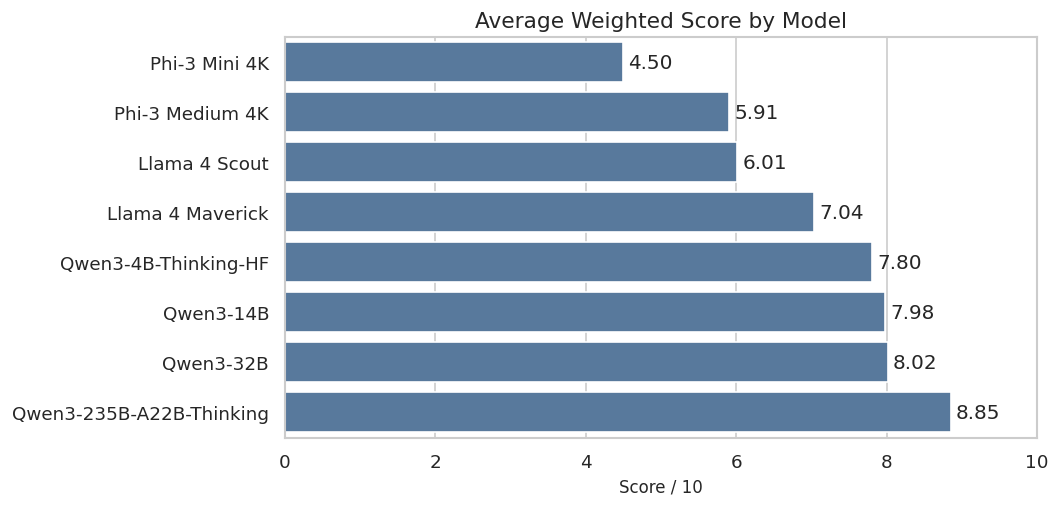

In [8]:
leaderboard = (
    scored_df.groupby("model_name", dropna=False)
    .agg(
        count=("weighted_score", "size"),
        avg_score=("weighted_score", "mean"),
        median_score=("weighted_score", "median"),
        min_score=("weighted_score", "min"),
        max_score=("weighted_score", "max"),
        avg_missing=("missing_count", "mean"),
        avg_issues=("issue_count", "mean"),
    )
    .sort_values("avg_score", ascending=False)
    .round(3)
)
display(leaderboard)

fig, ax = plt.subplots(figsize=(9, max(3.5, 0.55 * len(leaderboard))))
plot_df = leaderboard.reset_index().sort_values("avg_score")
sns.barplot(data=plot_df, y="model_name", x="avg_score", ax=ax, color="#4c78a8")
ax.set_xlim(0, 10)
ax.set_title("Average Weighted Score by Model")
ax.set_xlabel("Score / 10")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
savefig(fig, "01_model_leaderboard.png")

## 9. Phân phối điểm

Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4/02_score_distribution.png


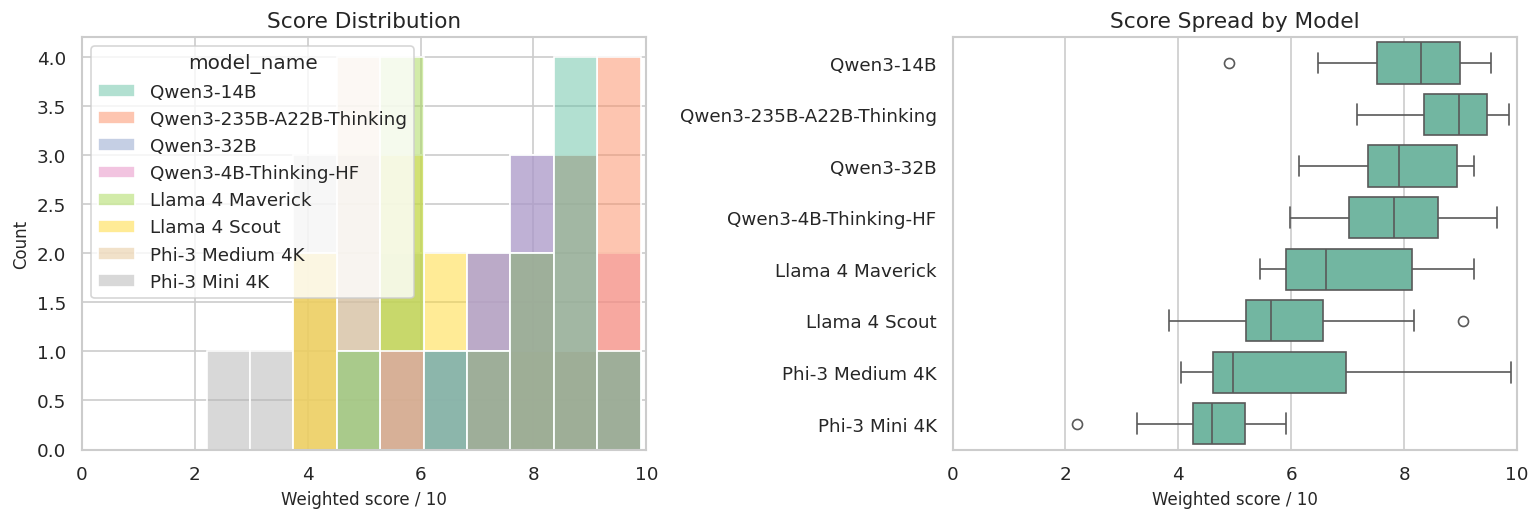

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(data=scored_df, x="weighted_score", hue="model_name", bins=10, multiple="layer", ax=axes[0])
axes[0].set_xlim(0, 10)
axes[0].set_title("Score Distribution")
axes[0].set_xlabel("Weighted score / 10")

sns.boxplot(data=scored_df, x="weighted_score", y="model_name", ax=axes[1])
axes[1].set_xlim(0, 10)
axes[1].set_title("Score Spread by Model")
axes[1].set_xlabel("Weighted score / 10")
axes[1].set_ylabel("")
savefig(fig, "02_score_distribution.png")

## 10. Điểm theo difficulty và category

Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4/03_score_by_difficulty_category.png


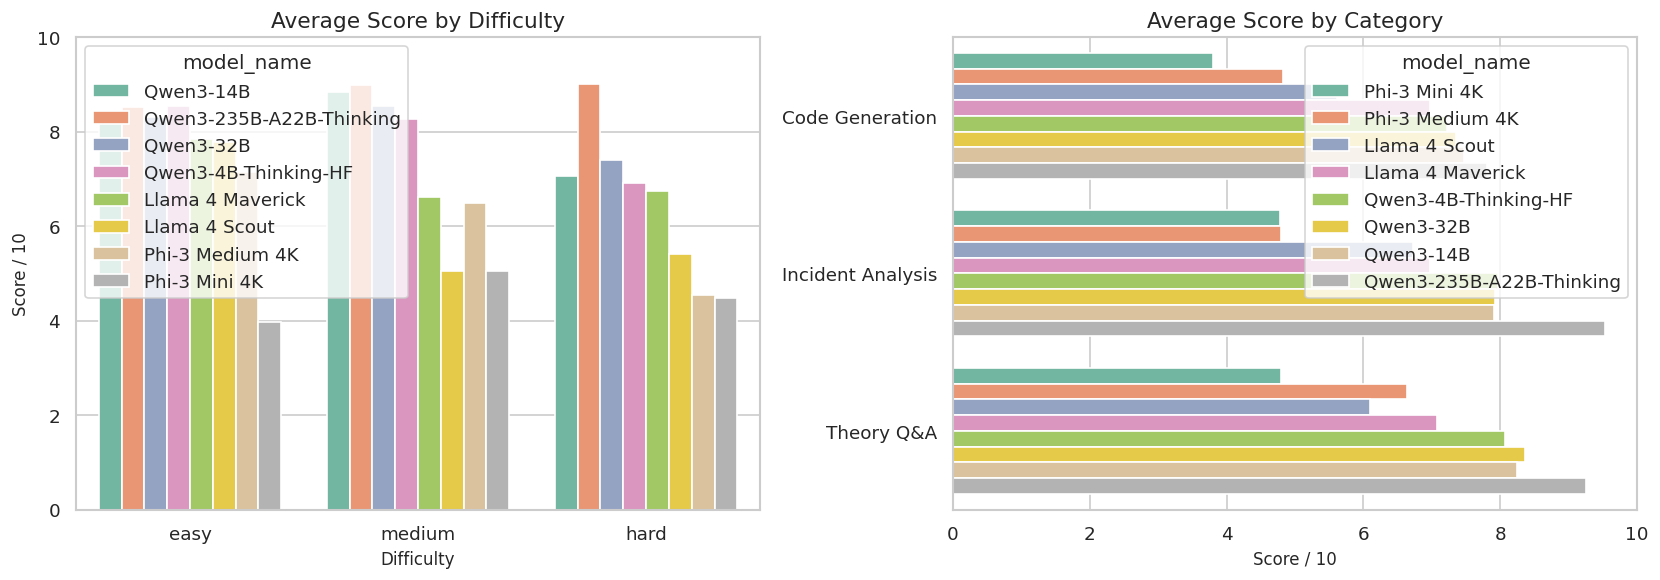

In [10]:
difficulty_order = ["easy", "medium", "hard"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=scored_df, x="difficulty", y="weighted_score", hue="model_name", order=difficulty_order, errorbar=None, ax=axes[0])
axes[0].set_ylim(0, 10)
axes[0].set_title("Average Score by Difficulty")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Score / 10")

cat = (
    scored_df.groupby(["category", "model_name"], as_index=False)["weighted_score"]
    .mean()
    .sort_values("weighted_score")
)
sns.barplot(data=cat, y="category", x="weighted_score", hue="model_name", errorbar=None, ax=axes[1])
axes[1].set_xlim(0, 10)
axes[1].set_title("Average Score by Category")
axes[1].set_xlabel("Score / 10")
axes[1].set_ylabel("")
savefig(fig, "03_score_by_difficulty_category.png")

## 11. Heatmap category x model

Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4/04_category_model_heatmap.png


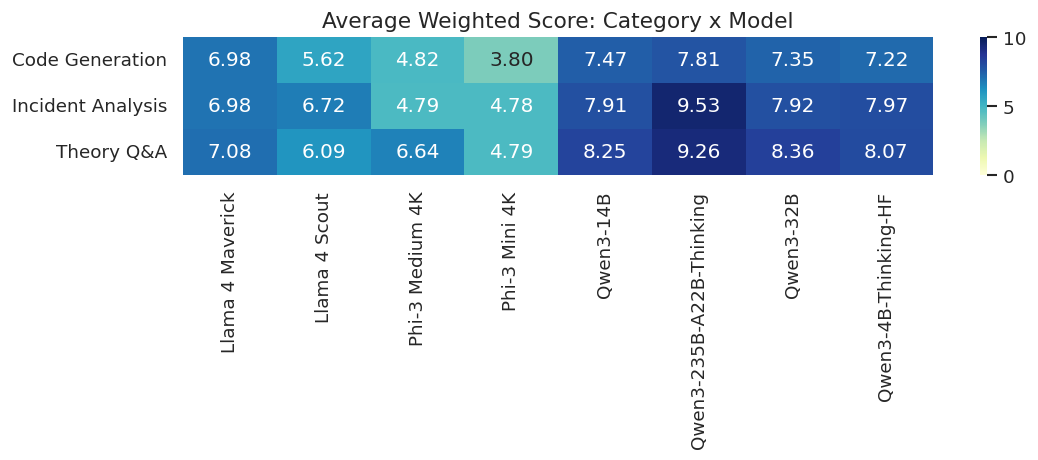

In [11]:
pivot_category = scored_df.pivot_table(
    index="category",
    columns="model_name",
    values="weighted_score",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(max(7, 1.2 * len(pivot_category.columns)), max(4, 0.45 * len(pivot_category))))
sns.heatmap(pivot_category, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=10, ax=ax)
ax.set_title("Average Weighted Score: Category x Model")
ax.set_xlabel("")
ax.set_ylabel("")
savefig(fig, "04_category_model_heatmap.png")

## 12. Heatmap metric x model

Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4/05_metric_model_heatmap.png


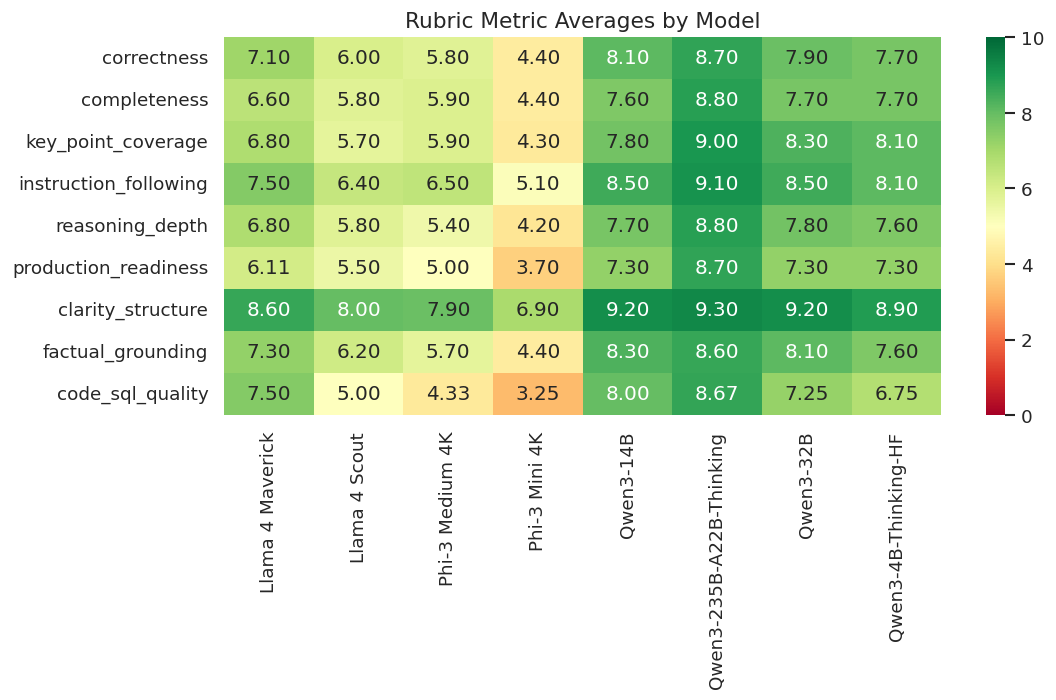

In [12]:
metric_scored = metric_df[metric_df["score"].notna()].copy()
pivot_metric = metric_scored.pivot_table(
    index="metric",
    columns="model_name",
    values="score",
    aggfunc="mean",
).reindex(metric_names)

fig, ax = plt.subplots(figsize=(max(7, 1.2 * len(pivot_metric.columns)), 6))
sns.heatmap(pivot_metric, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=10, ax=ax)
ax.set_title("Rubric Metric Averages by Model")
ax.set_xlabel("")
ax.set_ylabel("")
savefig(fig, "05_metric_model_heatmap.png")

## 13. Radar metric profile

Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4/06_metric_radar.png


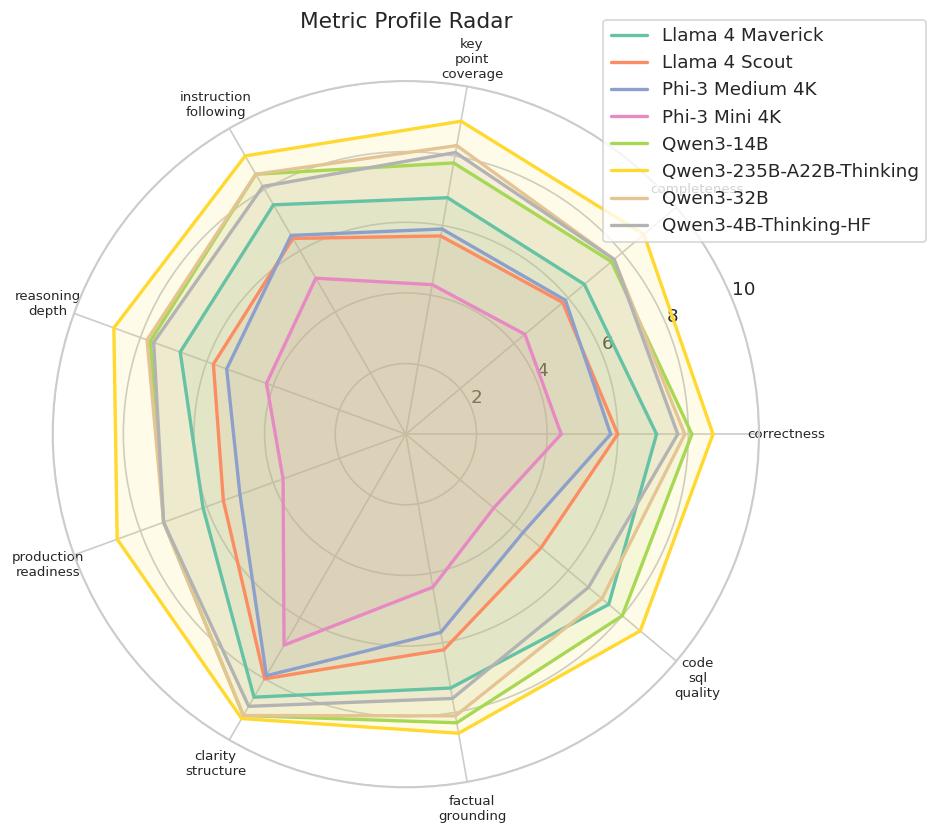

In [13]:
import math

radar_metrics = [metric for metric in metric_names if metric != "code_sql_quality" or pivot_metric.loc[metric].notna().any()]
angles = [n / float(len(radar_metrics)) * 2 * math.pi for n in range(len(radar_metrics))]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
for model_name in pivot_metric.columns:
    values = [pivot_metric.loc[metric, model_name] if metric in pivot_metric.index else None for metric in radar_metrics]
    values = [0 if pd.isna(value) else float(value) for value in values]
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([metric.replace("_", "\n") for metric in radar_metrics], fontsize=8)
ax.set_ylim(0, 10)
ax.set_title("Metric Profile Radar")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
savefig(fig, "06_metric_radar.png")

## 14. Output length, missing points và factual issues

Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4/07_length_missing_issues.png


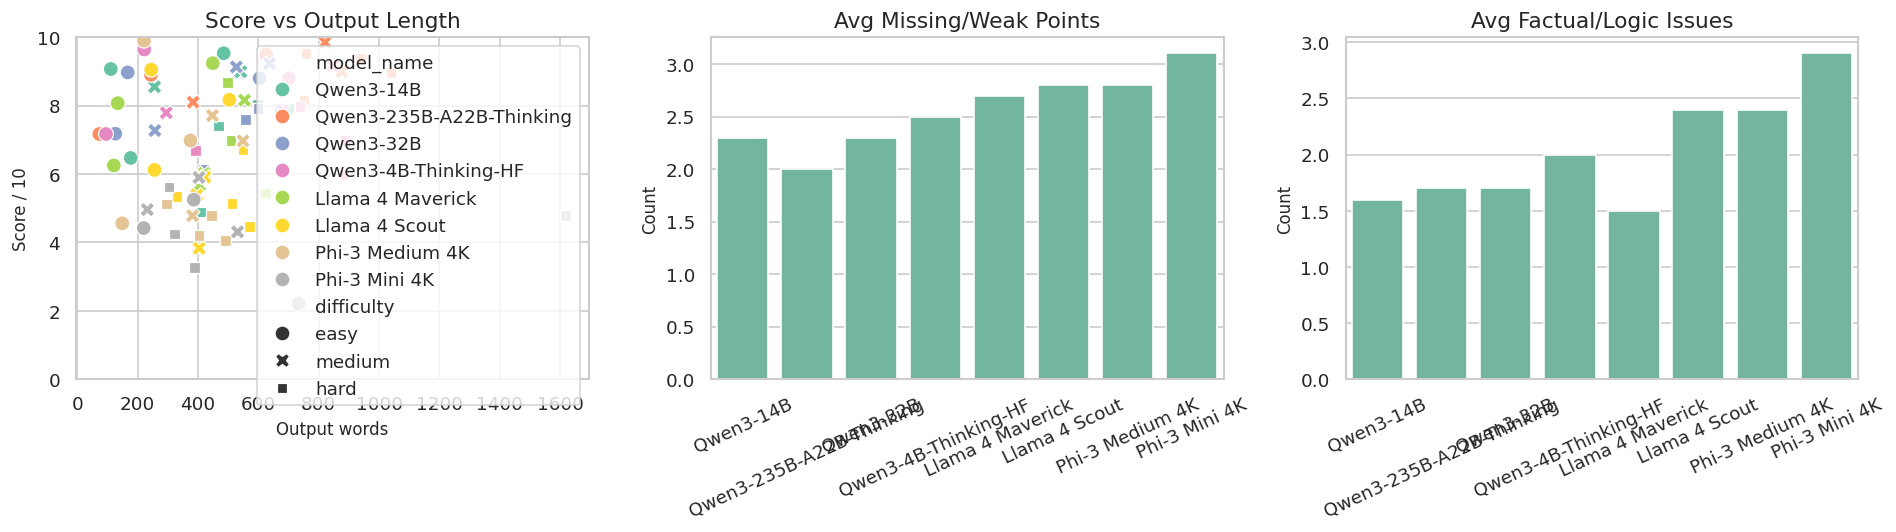

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
sns.scatterplot(data=scored_df, x="output_words", y="weighted_score", hue="model_name", style="difficulty", s=80, ax=axes[0])
axes[0].set_ylim(0, 10)
axes[0].set_title("Score vs Output Length")
axes[0].set_xlabel("Output words")
axes[0].set_ylabel("Score / 10")

sns.barplot(data=scored_df, x="model_name", y="missing_count", errorbar=None, ax=axes[1])
axes[1].set_title("Avg Missing/Weak Points")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=scored_df, x="model_name", y="issue_count", errorbar=None, ax=axes[2])
axes[2].set_title("Avg Factual/Logic Issues")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=25)
savefig(fig, "07_length_missing_issues.png")

## 15. Bảng câu điểm thấp nhất

In [15]:
low_cols = [
    "sample_id",
    "model_name",
    "difficulty",
    "category",
    "topic",
    "weighted_score",
    "judge_overall_score",
    "missing_count",
    "issue_count",
    "verdict",
]
low_scores = scored_df.sort_values("weighted_score").head(10)
display(low_scores[low_cols])

for _, row in low_scores.iterrows():
    original = next(item for item in results if item.get("sample_id") == row["sample_id"] and (item.get("model_name") or "unknown") == row["model_name"])
    judge = original.get("judge") or {}
    display(Markdown(f"### {row['sample_id']} - {row['model_name']} - {row['weighted_score']}/10"))
    display(Markdown(f"**Topic:** {row['topic']}"))
    missing = judge.get("missing_or_weak_points") or []
    issues = judge.get("factual_or_logic_issues") or []
    if missing:
        display(Markdown("**Missing / weak:**\n" + "\n".join(f"- {point}" for point in missing)))
    if issues:
        display(Markdown("**Factual / logic issues:**\n" + "\n".join(f"- {issue}" for issue in issues)))

,sample_id,model_name,difficulty,category,topic,weighted_score,judge_overall_score,missing_count,issue_count,verdict
76,BD_CODE_EASY_01,Phi-3 Mini 4K,easy,Code Generation,PySpark batch aggregation,2.21,3.0,3,4,Code adds unrequested features and fails core ...
74,BD_THEORY_HARD_01,Phi-3 Mini 4K,hard,Theory Q&A,Small-file problem in Spark,3.27,3.0,4,3,"Answer is mostly wrong on root causes, misses ..."
52,BD_THEORY_MEDIUM_01,Llama 4 Scout,medium,Theory Q&A,repartition vs coalesce in Apache Spark,3.83,4.0,3,3,Partially correct but contains critical factua...
65,BD_THEORY_HARD_02,Phi-3 Medium 4K,hard,Theory Q&A,Spark performance optimization techniques,4.05,4.0,5,4,Answer provides a structured list with bottlen...
64,BD_THEORY_HARD_01,Phi-3 Medium 4K,hard,Theory Q&A,Small-file problem in Spark,4.21,4.0,3,3,Answer partially addresses the problem but con...
78,BD_CODE_HARD_01,Phi-3 Mini 4K,hard,Code Generation,Production-style PySpark pipeline with dedupli...,4.24,4.0,3,3,Partially correct but flawed in key aggregatio...
72,BD_THEORY_MEDIUM_01,Phi-3 Mini 4K,medium,Theory Q&A,repartition vs coalesce in Apache Spark,4.31,5.0,3,2,Partially correct but contains significant fac...
70,BD_THEORY_EASY_01,Phi-3 Mini 4K,easy,Theory Q&A,Managed vs External tables in Hive/Spark,4.42,4.0,3,5,Answer covers required sections and DROP behav...
54,BD_THEORY_HARD_01,Llama 4 Scout,hard,Theory Q&A,Small-file problem in Spark,4.47,4.0,3,3,"Partially correct but misses key root causes, ..."
66,BD_CODE_EASY_01,Phi-3 Medium 4K,easy,Code Generation,PySpark batch aggregation,4.56,5.0,3,3,Partially correct but flawed due to separate a...


### BD_CODE_EASY_01 - Phi-3 Mini 4K - 2.21/10

**Topic:** PySpark batch aggregation

**Missing / weak:**
- No event_date column for partitioning
- Separate aggregations instead of single groupBy
- Partition column missing in dataframes

**Factual / logic issues:**
- Uses F.date_trunc incorrectly, missing column name
- Filters revenue >0, not in requirements
- Adds ARPU and ranking, not requested
- Fills nulls with mode, not required

...

**Factual / logic issues:**
- Focuses on HDFS NameNode, not object stores like S3/ADLS
- Mentions 'wholeTextFile' which is irrelevant for general small-file problem
- Suggests 'hadoop fs -getmerge' which is not a Spark solution

### BD_CODE_EASY_01 - Phi-3 Medium 4K - 4.56/10

**Topic:** PySpark batch aggregation

**Missing / weak:**
- No event_date column in main DF
- Two separate writes instead of one
- Missing mode specification for write

**Factual / logic issues:**
- Separate aggregations create two datasets
- Missing coalesce for null revenue
- Uses /path/to/save instead of specified path

## 16. Xuất bảng tổng hợp

In [16]:
JUDGE_TABLES_DIR.mkdir(parents=True, exist_ok=True)
dashboard_csv = JUDGE_TABLES_DIR / "llm_dashboard_table.csv"
metric_csv = JUDGE_TABLES_DIR / "llm_metric_long_table.csv"
leaderboard_csv = JUDGE_TABLES_DIR / "llm_model_leaderboard.csv"

scored_df.to_csv(dashboard_csv, index=False, encoding="utf-8")
metric_df.to_csv(metric_csv, index=False, encoding="utf-8")
leaderboard.to_csv(leaderboard_csv, encoding="utf-8")

print("Saved:", dashboard_csv)
print("Saved:", metric_csv)
print("Saved:", leaderboard_csv)
print("Visuals:", VISUAL_DIR)

Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/tables/llm_dashboard_table.csv
Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/tables/llm_metric_long_table.csv
Saved: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/tables/llm_model_leaderboard.csv
Visuals: /home/phat/AI_Project/a-triple-of-lms/outputs/llm_judge/visuals/llama4
